<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme des régions de confiance </h1>
</center>

# Régions de confiance avec Pas de Cauchy 

## Implémentation 

1. Coder l'algorithme du pas de Cauchy dans le fichier `src/cauchy.jl`). La spécification de cet algorithme est donnée dans le fichier.
2. Ecrire des tests exhaustifs (qui testent tous les cas de figure possibles) pour votre algorithme du pas de Cauchy. Vous remplirez pour cela le fichier `test/tester_cauchy.jl` sur le modèle des autres fichiers de tests et vous exécuterez dans la cellule de code ci-après ces tests.

In [1]:
include("../src/cauchy.jl")         # votre algorithme
include("../test/tester_cauchy.jl") # la fonction pour tester votre algorithme

#
tester_cauchy(cauchy); # tester l'algorithme

Test Summary: | Pass  Total  Time
Pas de Cauchy |    5      5  0.2s


3. Coder l'algorithme des régions de confiance (fichier `src/regions_de_confiance.jl`). Sa spécification est donnée dans le fichier.
4. Vérifier que les tests ci-dessous passent.

In [2]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_cauchy.jl")

#
afficher = true # si true, alors affiche les résultats des algorithmes

#
tester_rc_cauchy(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : true

-------------------------------------------------------------------------
Résultats de : RC et cauchy appliqué à f1:
  * x0       = [1, 0, 0]
  * x_sol    = [1.0000065049853921, 1.000000873235793, 0.9999952414861938]
  * f(x_sol) = 7.71589405988668e-11
  * nb_iters = 33
  * flag     = 2
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : RC et cauchy appliqué à f1:
  * x0       = [10.0, 3.0, -2.2]
  * x_sol    = [1.000003643199092, 0.9999997146801121, 0.9999957861612833]
  * f(x_sol) = 3.233185493810428e-11
  * nb_iters = 34
  * flag     = 2
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : RC et cauchy appliqué à f2:
  * x0       = [-1.2, 1.0]
  * x_sol    = [0.9993529197792448, 0.998704294109285]
  * f(x_sol) = 4.1909860533540065e-7
  * nb_iters = 5000
  * flag     = 3
  * solution = [1, 1]
----------------------

## Interprétation 

<!-- Pour ces questions, des représentations graphiques sont attendues pour corroborer vos réponses. -->

1. Soit la fonction $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$ définie par
$$ 
    f_1(x_1,x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$ 
Quelle relation lie la fonction $f_1$ et son modèle de Taylor à l’ordre 2 ? Comparer alors les performances de l'algorithme de Newton et celui des régions de confiance avec le pas de Cauchy sur cette fonction.

2. Le rayon initial de la région de confiance est un paramètre important dans l’analyse
de la performance de l’algorithme. Sur quel(s) autre(s) paramètre(s) peut-on jouer
pour essayer d’améliorer cette performance ? Étudier l’influence d’au moins deux de
ces paramètres. Pour cela vous ferez des tests numériques et donnerez les résultats sous forme de tableaux et de graphiques.

## Réponse à la Question 1 :

On s'intéresse à la fonction $f_{1}$ ci-dessous : 
$$ f_1(x_1,x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2 $$

On peut noter que la fonction $f_{1}$ est la même que son développement Taylor à l'ordre 2 car elle est quadratique.

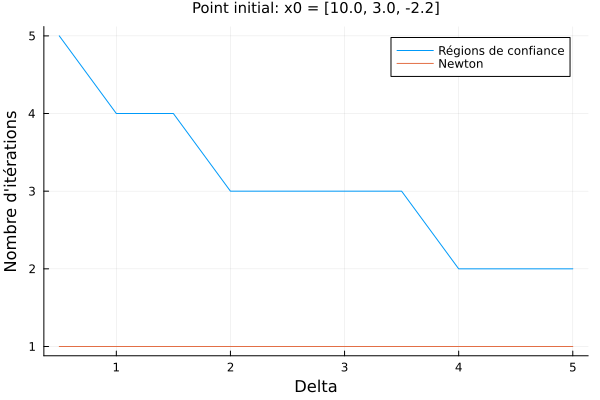

In [24]:
using Plots
include("../src/newton.jl")
include("../src/regions_de_confiance.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

x0 = [10.0, 3.0, -2.2]

_, _, _, iter_newton, _ = newton(f, gradf, hessf, x0)
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Liste_iter_regions = []
Liste_iter_newton = fill(iter_newton, length(deltas))

for delta in deltas
    x_regions, _, _, iter_regions, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta)
    push!(Liste_iter_regions, iter_regions)
end

plot(deltas, Liste_iter_regions, label="Régions de confiance", xlabel="Delta", ylabel="Nombre d'itérations", title="Point initial: x0 = $x0", titlefontsize=10)
plot!(deltas, Liste_iter_newton, label="Newton")


En traçant l'évolution du nombre d'itérations en fonction de Delta on peut arriver à conclure quant à la performance des deux algorithmes. 
On peut remarquer que pour le point initial choisi, la méthode de newton converge en uniquement une itération. 
Interessons nous donc maintenant à l'impact de la valeur de delta sur la performance de l'algorithme de region de confiance. 

De manière générale, plus Delta est petit, plus le critère de convergence devient difficile à atteindre (la précision devenant plus importante) et donc plus le nombre d'itération est grand. Ici, lorsque Delta vaut 0.5, l'algorithme de région de confiance converge en 5 itérations tandis que celui de Newton converge en 1 itération. 

Cependant, pour une valeur de Delta assez grande, l'algorithme devient équivalent à celui de Newton en terme de performance, il y a une contrainte de précision qui est plus large et la convergence devient plus facilement accessible. Ainsi, avec une valeur de Delta suffisamment grande, on arrive à otenir une convergence en seulement une itération comme pour l'algorithme de Newton.

De manière générale, l'algorithe de Newton semble être plus efficace que celui de region de confiance.

## Réponse à la Question 2 :

En plus du rayon initial de la région de confiance, plusieurs autres paramètres peuvent influencer la performance de 
l'algorithme des régions de confiance :

- Les différents critères d'arrêt peuvent être ajustés pour obtenir un compromis entre la précision de la solution et le nombre d'itérations.
- Un bon choix du point initial peut réduire le nombre d'itérations nécessaires pour converger, en particulier si ce dernier est proche de la solution attendue
- Un bon choix de Delta (utiliser comme condition de convergence) permet d'optimiser également l'algorithme. 

Dans la suite, nous étudierons l'impact de la variation du choix du point initial et celle de Delta sur la performance de l'algorithme de la region de confiance. 

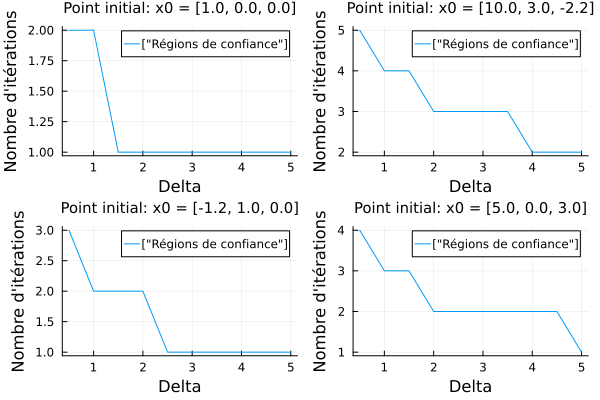

In [25]:
using Plots
include("../src/newton.jl")
include("../src/regions_de_confiance.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

PointsInitiaux = [
    [1.0, 0.0, 0.0],
    [10.0, 3.0, -2.2],
    [-1.2, 1.0, 0.0],
    [5.0, 0.0, 3.0]
]

l = @layout [a b; c d]

p = plot(layout = l, xlabel="Delta", ylabel="Nombre d'itérations", legend=:topright)

for (i, x0) in enumerate(PointsInitiaux)
    deltas = [0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
    Liste_iter_regions = []

    for delta in deltas
        x_regions, _, _, iter_regions, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta)
        push!(Liste_iter_regions, iter_regions)
    end

    plot!(deltas, Liste_iter_regions, 
          xlabel="Delta", ylabel="Nombre d'itérations", 
          label=["Régions de confiance"], 
          title="Point initial: x0 = $(x0)", 
          titlefontsize=10, 
          subplot=i)
end

display(p)

En traçant l'évolution du nombre d'itérations en fonction des différentes valeurs de Delta et pour différentes valeurs initiale de x0, on peut arriver à conclure quant à la performance de l'algorithme de region de confiance. 

Interessons nous donc maintenant à l'impact du choix de la position initiale et des valeurs de delta sur la performance de l'algorithme. 

De manière générale, plus Delta est petit, plus le critère de convergence devient difficile à atteindre et donc plus le nombre d'itération est grand. 

De même, le choix de la variable initiale a son importance, et influe sur la valeur du nombre d'itérations lorsque Delta est relativement petit. 

- 1er cas : Dans ce cas, x0 = [1.0 , 0.0 , 0. 0] est assez proche de la solution attendue. Pour une valeur petite de Delta, l'algorithme converge en seulement deux itérations vers la solution. 
- 2ème cas : Dans ce cas, x0 = [10.0, 3.0, -2.2] est assez loin de la solution attendue. Pour une valeur petite de Delta, l'algorithme converge en 5 itérations vers la solution. Ce choix du point initial détériore donc la performance de l'algortihme comparé au choix de x0 du cas 1. 
- De manière analogue, le 3ème et le 4ème cas, que pour un Delta relativement petit, l'algorithme converge en 3 (resp. 4) itérations. Sans grandes surprises, ces valeurs sont inférieures au nombre d'itérations obtenu pour le cas 2, car le choix des x0 initiaux sont plus proche de la solution souhaitée que le 2ème cas.

Enfin, on peut en conclure que le choix de la valeur initiale, et le choix du Delta influe énormément sur la rapidité de convergence de l'algorithme de region de confiance, et qu'un choix optimal de ces deux valeurs permettrait d'améliorer la performance de l'algorithme.

# Régions de confiance avec gradient conjugué tronqué

## Implémentation 

1. Implémenter l’algorithme du gradient conjugué tronqué (fichier `src/gct.jl`). Sa spécification est dans le fichier.
2. Vérifier que les tests ci-dessous passent.

In [14]:
include("../src/gct.jl")
include("../test/tester_gct.jl")

#
tester_gct(gct);

Test Summary:             | Pass  Total  Time
Gradient conjugué tronqué |    9      9  0.0s


3. Intégrer l’algorithme du gradient conjugué tronqué dans le code des régions de confiance.
4. Vérifier que les tests ci-dessous passent.

In [3]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_gct.jl")

#
afficher = true # si true, alors affiche les résultats des algorithmes

#
tester_rc_gct(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : true

-------------------------------------------------------------------------
Résultats de : RC et gct appliqué à f1:
  * x0       = [1, 0, 0]
  * x_sol    = [1.0000000000000004, 1.0000000000000002, 1.0000000000000002]
  * f(x_sol) = 1.627025617018337e-30
  * nb_iters = 1
  * flag     = 0
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : RC et gct appliqué à f1:
  * x0       = [10.0, 3.0, -2.2]
  * x_sol    = [0.9999999999999996, 1.0000000000000004, 1.0]
  * f(x_sol) = 9.860761315262648e-31
  * nb_iters = 3
  * flag     = 0
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : RC et gct appliqué à f2:
  * x0       = [-1.2, 1.0]
  * x_sol    = [0.999999674378009, 0.999999347837161]
  * f(x_sol) = 1.0611413032942621e-13
  * nb_iters = 31
  * flag     = 0
  * solution = [1, 1]
-----------------------------------------------

## Interprétation  

Nous proposons de comparer l'utilisation du pas de Cauchy avec celle du gradient conjugué tronqué dans l'algorithme des régions de confiance.

**Remarques.**
* Nous vous demandons de réaliser des expérimentations numériques pour les comparaisons demandées ci-après.
* Vous devez utiliser l'argument optionnel `max_iter_gct` et la sortie `xs` de l'algorithme des régions de confiance.
* Vous pouvez comparer l'écart en norme entre les itérés de l'algorithme et la solution du problème.
* Vous trouverez des choses utiles dans le fichier `test/fonctions_de_tests.jl`.

1. Comparer dans le cas où l'on force le gradient conjugué tronqué à ne faire qu'une seule itération. Que remarquez vous ?
2. Comparer dans le cas général. Que remarquez vous ?
3. Quels sont les avantages et inconvénients des deux approches ?

# Réponse à la Question 1 :


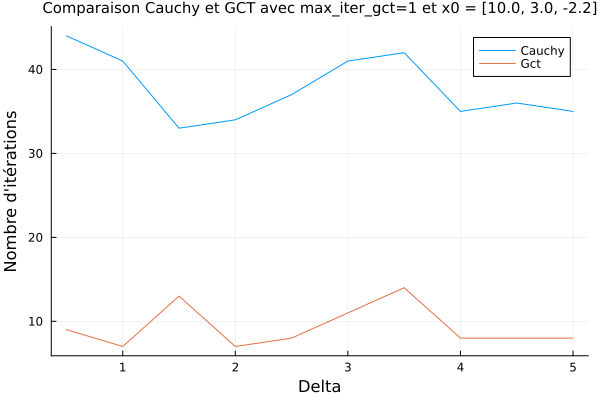

In [16]:
using Plots
include("../src/newton.jl")
include("../src/regions_de_confiance.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

x0 = [10.0, 3.0, -2.2]

deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Liste_iter_regions_cauchy = []
Liste_iter_regions_gct = []

for delta in deltas
    _, _, _, iter_regions_cauchy, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="cauchy")
    push!(Liste_iter_regions_cauchy, iter_regions_cauchy)
    _, _, _, iter_regions_gct, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="gct", max_iter_gct=1)
    push!(Liste_iter_regions_gct, iter_regions_gct)
end

plot(deltas, Liste_iter_regions_cauchy, label="Cauchy", xlabel="Delta", ylabel="Nombre d'itérations", title="Comparaison Cauchy et GCT avec max_iter_gct=1 et x0 = $x0", titlefontsize=10)
plot!(deltas, Liste_iter_regions_gct, label="Gct")


On peut remarquer dans la figure obtenue, que globalement, l'utilisation de l'algorithme du gradient conjugué tronqué dans la région de confiance est beaucoup plus efficace que l'algorithme de Cauchy. En effet, peut importe la valeur de delta donnée, le nombre d'itérations de Cauchy est environ 4 fois plus grand que celui de GCT. On peut donc en conclure que l'algorithme de GCT converge plus rapidement et est donc plus optimal que celui de Cauchy.

# Réponse à la Question 2 :


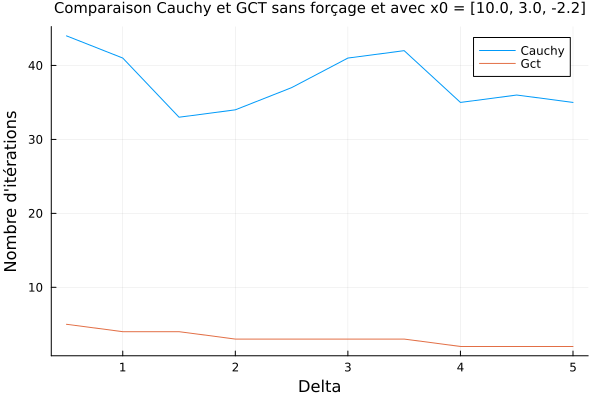

In [17]:
using Plots
include("../src/newton.jl")
include("../src/regions_de_confiance.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

x0 = [10.0, 3.0, -2.2]

deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Liste_iter_regions_cauchy = []
Liste_iter_regions_gct = []

for delta in deltas
    _, _, _, iter_regions_cauchy, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="cauchy")
    push!(Liste_iter_regions_cauchy, iter_regions_cauchy)
    _, _, _, iter_regions_gct, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="gct")
    push!(Liste_iter_regions_gct, iter_regions_gct)
end

plot(deltas, Liste_iter_regions_cauchy, label="Cauchy", xlabel="Delta", ylabel="Nombre d'itérations", title="Comparaison Cauchy et GCT sans forçage et avec x0 = $x0", titlefontsize=10)
plot!(deltas, Liste_iter_regions_gct, label="Gct")


La figure obtenueLe Gradient Conjugué Tronqué converge généralement en bien moins d’itérations que la méthode de Cauchy, particulièrement pour des valeurs de delta plus grandes. On remarque également que lorsqu'on ne force pas le nombred d'itération de gct à 1, le nombre d'itération demeure toujours ici inférieur à 5, alors que pour les mêmes conditions, le nombre d'itération de l'algorithme gct forcé à une itération. L'algorithme sans forçage est donc plus rapide et plus efficace. 


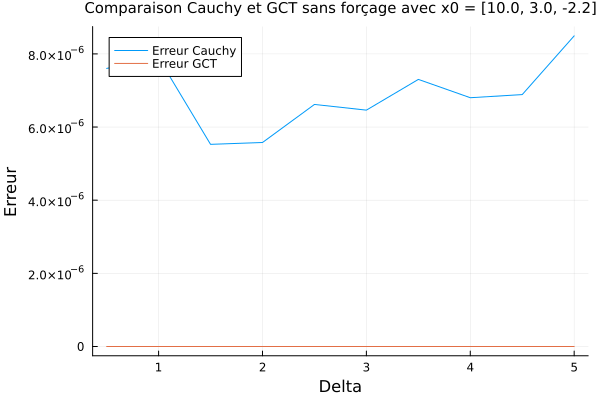

In [20]:
using Plots
include("../src/newton.jl")
include("../src/regions_de_confiance.jl")

f(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2

gradf(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]),
            4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])]

hessf(x) = [6 2 4; 2 8 2; 4 2 6]

sol = [1.0, 1.0, 1.0]
x0 = [10.0, 3.0, -2.2]

deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Liste_erreurs_cauchy = []
Liste_erreurs_gct = []

for delta in deltas
    x_cauchy, _, _, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="cauchy")
    push!(Liste_erreurs_cauchy, norm(sol - x_cauchy))
    
    x_gct, _, _, _ = regions_de_confiance(f, gradf, hessf, x0, Δ0=delta; algo_pas="gct")
    push!(Liste_erreurs_gct, norm(sol - x_gct))
end

plot(deltas, Liste_erreurs_cauchy, label="Erreur Cauchy", xlabel="Delta", ylabel="Erreur", title="Comparaison Cauchy et GCT sans forçage avec x0 = $x0", titlefontsize=10)
plot!(deltas, Liste_erreurs_gct, label="Erreur GCT")

De plus, cette figure permet de montrer que l'algorithme de GCT est meilleur également en terme de performance puisque le resultat obtenu est plus précis qu'en utilisant l'algorithme de Cauchy. Les deux courbes obtenues montrent que la difference de précision est de l'ordre de $10⁶$. 

# Réponse à la Question 3 :


La méthode de Cauchy est simple à écrire, mais elle présente plusieurs inconvénients. Elle n'est pas optimale, notamment à cause des erreurs de précision qui peuvent apparaître, et elle est assez lente, surtout pour des calculs plus complexes. En revanche, la méthode GCT, bien que plus rapide et précise, est plus difficile à implémenter en raison de sa complexité technique.